# User Compatibility Engine for Project Collaboration

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

data_size = 900

data = pd.DataFrame({
    "skill_diff": np.random.randint(0, 6, data_size),
    "same_tech_stack": np.random.randint(0, 2, data_size),
    "availability_overlap": np.random.randint(0, 10, data_size),
    "communication_gap": np.random.randint(0, 5, data_size),
    "experience_gap": np.random.randint(0, 6, data_size),
    "project_interest_match": np.random.randint(0, 2, data_size),
    "work_style_match": np.random.randint(0, 2, data_size),
    "problem_solving_gap": np.random.randint(0, 5, data_size),
    "commitment_level_diff": np.random.randint(0, 5, data_size),
    "past_collab_success": np.random.randint(0, 2, data_size),
})

In [3]:
score = (
    (data["skill_diff"] <= 2).astype(int) * 2 +
    data["same_tech_stack"] * 2 +
    (data["availability_overlap"] >= 6).astype(int) * 2 +
    (data["communication_gap"] <= 2).astype(int) * 2 +
    (data["experience_gap"] <= 3).astype(int) +
    data["project_interest_match"] * 2 +
    data["work_style_match"] +
    (data["problem_solving_gap"] <= 2).astype(int) +
    (data["commitment_level_diff"] <= 2).astype(int) +
    data["past_collab_success"]
)

# Balanced threshold
data["compatible"] = (score >= 9).astype(int)

In [4]:
noise_idx = np.random.choice(data.index, size=int(0.04 * data_size), replace=False)
data.loc[noise_idx, "compatible"] = 1 - data.loc[noise_idx, "compatible"]

In [5]:
data.to_csv("dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [6]:
X = data.drop("compatible", axis=1)
y = data["compatible"]

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [7]:
model = RandomForestClassifier(
    n_estimators=250,
    max_depth=14,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [8]:
y_pred = model.predict(X_test)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:

[[96  7]
 [13 64]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       103
           1       0.90      0.83      0.86        77

    accuracy                           0.89       180
   macro avg       0.89      0.88      0.89       180
weighted avg       0.89      0.89      0.89       180

Accuracy: 0.8888888888888888


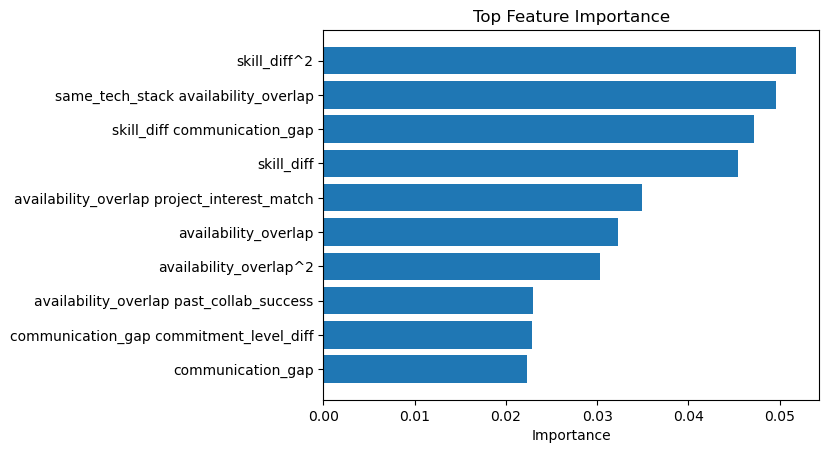

In [9]:
feature_names = poly.get_feature_names_out(X.columns)
importances = model.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top Feature Importance")
plt.xlabel("Importance")
plt.show()

In [10]:
user_pair = [[
    1,  # skill_diff
    1,  # same_tech_stack
    7,  # availability_overlap
    1,  # communication_gap
    2,  # experience_gap
    1,  # project_interest_match
    1,  # work_style_match
    1,  # problem_solving_gap
    1,  # commitment_level_diff
    1   # past_collab_success
]]

user_pair_poly = poly.transform(user_pair)

prediction = model.predict(user_pair_poly)

if prediction[0] == 1:
    print("Strong Collaboration Pair")
else:
    print("Not Suitable for Collaboration")

Strong Collaboration Pair


C:\Users\sharw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [12]:
user_pair = [[
    4,  # skill_diff
    0,  # same_tech_stack
    2,  # availability_overlap
    4,  # communication_gap
    5,  # experience_gap
    0,  # project_interest_match
    0,  # work_style_match
    4,  # problem_solving_gap
    4,  # commitment_level_diff
    0   # past_collab_success
]]

user_pair_poly = poly.transform(user_pair)

prediction = model.predict(user_pair_poly)

if prediction[0] == 1:
    print("Strong Collaboration Pair")
else:
    print("Not Suitable for Collaboration")

Not Suitable for Collaboration


C:\Users\sharw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
